**EDA Stock Data**

Author: Jesús Enrique Miranda Blanco

# Setup

In [70]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# import pandas_datareader.data as web
import yfinance as yf

from scipy.stats import kurtosis


pd.set_option("display.max_columns",80)

In [2]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-02-28


# Data

In [3]:
%%time
start_date = "2018-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT", "NU"]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
all_data.info()

The number of stock to download are 11
[*********************100%***********************]  11 of 11 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1297 entries, 2018-01-02 00:00:00-05:00 to 2023-02-27 00:00:00-05:00
Data columns (total 66 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1297 non-null   float64
 1   (Adj Close, DIS)    1297 non-null   float64
 2   (Adj Close, KO)     1297 non-null   float64
 3   (Adj Close, MAT)    1297 non-null   float64
 4   (Adj Close, META)   1297 non-null   float64
 5   (Adj Close, MSFT)   1297 non-null   float64
 6   (Adj Close, NU)     305 non-null    float64
 7   (Adj Close, NVDA)   1297 non-null   float64
 8   (Adj Close, PFE)    1297 non-null   float64
 9   (Adj Close, TSLA)   1297 non-null   float64
 10  (Adj Close, ^GSPC)  1297 non-null   float64
 11  (Close, AAPL)       1297 non-null   float64
 12  (Close, DIS)        1297 non-null   float64


## Missing review

In [4]:
df_missings_agg = all_data.isna().sum().sort_values()
df_missings_agg[
    df_missings_agg > 0
]

Low        NU    992
Adj Close  NU    992
Open       NU    992
Volume     NU    992
High       NU    992
Close      NU    992
dtype: int64

In [59]:
adj_close_data_completed = all_data["Adj Close"].copy()
adj_close_data_completed.head()

,AAPL,DIS,KO,MAT,META,MSFT,NU,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.888073,108.726059,38.843891,16.020000,181.419998,80.738159,NaN,49.334671,28.559772,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.880943,109.192848,38.758598,16.139999,184.669998,81.113899,NaN,52.581573,28.771393,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.070839,109.144241,39.304485,15.910000,184.330002,81.827843,NaN,52.858753,28.834085,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.538437,108.551003,39.295959,16.260000,186.850006,82.842339,NaN,53.306683,28.888956,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.384163,106.994987,39.236244,15.810000,188.279999,82.926888,NaN,54.940041,28.567612,22.427334,2747.709961


In [60]:
adj_close_data_completed[
    adj_close_data_completed.NU.notna()
].isna().sum()#.index.min()

AAPL     0
DIS      0
KO       0
MAT      0
META     0
MSFT     0
NU       0
NVDA     0
PFE      0
TSLA     0
^GSPC    0
dtype: int64

In [61]:
adj_close_data_completed[
    adj_close_data_completed.NU.notna()
].index.min()

Timestamp('2021-12-09 00:00:00-0500', tz='America/New_York')

In [63]:
"AAPL" in adj_close_data_completed.columns

True

In [64]:
"prueba" in adj_close_data_completed.columns

False

In [66]:
adj_close_data = adj_close_data_completed.drop(columns=['NU','prueba'],errors='ignore').copy()
adj_close_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.888073,108.726059,38.843891,16.020000,181.419998,80.738159,49.334671,28.559772,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.880943,109.192848,38.758598,16.139999,184.669998,81.113899,52.581573,28.771393,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.070839,109.144241,39.304485,15.910000,184.330002,81.827843,52.858753,28.834085,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.538437,108.551003,39.295959,16.260000,186.850006,82.842339,53.306683,28.888956,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.384163,106.994987,39.236244,15.810000,188.279999,82.926888,54.940041,28.567612,22.427334,2747.709961


# Transformations

## Returns 
$$r_{t+1}=\frac{p_{t+1} - p_{t}}{p_{t}}$$

In [13]:
(34.309586 - 38.105137) / 38.105137

-0.09960733115852585

In [14]:
(35.774239- 34.309586) / 34.309586

0.042689323036424816

In [15]:
yield_data = adj_close_data.pct_change()#.dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03 00:00:00-05:00,-0.000174,0.004293,-0.002196,0.007491,0.017914,0.004654,0.065814,0.007410,-0.010233,0.006399
2018-01-04 00:00:00-05:00,0.004645,-0.000445,0.014084,-0.014250,-0.001841,0.008802,0.005271,0.002179,-0.008290,0.004029
2018-01-05 00:00:00-05:00,0.011385,-0.005435,-0.000217,0.021999,0.013671,0.012398,0.008474,0.001903,0.006230,0.007034
2018-01-08 00:00:00-05:00,-0.003714,-0.014334,-0.001520,-0.027675,0.007653,0.001021,0.030641,-0.011123,0.062638,0.001662


In [16]:
yield_data = adj_close_data.pct_change().dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004293,-0.002196,0.007491,0.017914,0.004654,0.065814,0.007410,-0.010233,0.006399
2018-01-04 00:00:00-05:00,0.004645,-0.000445,0.014084,-0.014250,-0.001841,0.008802,0.005271,0.002179,-0.008290,0.004029
2018-01-05 00:00:00-05:00,0.011385,-0.005435,-0.000217,0.021999,0.013671,0.012398,0.008474,0.001903,0.006230,0.007034
2018-01-08 00:00:00-05:00,-0.003714,-0.014334,-0.001520,-0.027675,0.007653,0.001021,0.030641,-0.011123,0.062638,0.001662
2018-01-09 00:00:00-05:00,-0.000115,-0.000727,0.005000,0.000632,-0.002178,-0.000680,-0.000270,-0.001097,-0.008085,0.001303


## Log-returns

$$1+r_{t+1}= \frac{p_{t+1}}{p_{t}} = e^{log(\frac{p_{t+1}}{p_{t}} )}$$

In [17]:
df_log = np.log(yield_data + 1)
df_log.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004284,-0.002198,0.007463,0.017756,0.004643,0.063739,0.007382,-0.010286,0.006378
2018-01-04 00:00:00-05:00,0.004634,-0.000445,0.013986,-0.014353,-0.001843,0.008763,0.005258,0.002177,-0.008325,0.004021
2018-01-05 00:00:00-05:00,0.011321,-0.005450,-0.000217,0.021760,0.013579,0.012322,0.008438,0.001901,0.006210,0.007009
2018-01-08 00:00:00-05:00,-0.003721,-0.014438,-0.001521,-0.028065,0.007624,0.001020,0.030181,-0.011186,0.060755,0.001661
2018-01-09 00:00:00-05:00,-0.000115,-0.000727,0.004988,0.000632,-0.002180,-0.000680,-0.000270,-0.001098,-0.008118,0.001302


# Summary statistics

## Central tendency

### Mean

In [42]:
(
    df_log.pivot_table(
        index=df_log.index.year,
        aggfunc='mean'
    )*252
)

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018,-0.073741,-0.003715,0.073561,-0.476031,-0.327530,0.185619,-0.401360,0.217363,0.037866,-0.073253
2019,0.636354,0.289032,0.187304,0.304802,0.448345,0.454624,0.570658,-0.071581,0.228729,0.253697
2020,0.598147,0.224422,0.024295,0.251953,0.284699,0.353010,0.795681,0.030114,2.123887,0.150054
2021,0.297495,-0.156776,0.107710,0.211500,0.208095,0.421843,0.813071,0.510996,0.403834,0.238172
2022,-0.307804,-0.580491,0.101238,-0.190151,-1.031926,-0.330158,-0.701237,-0.110342,-1.054909,-0.217064
2023,0.870073,0.962456,-0.407382,0.132489,2.273092,0.296522,3.150418,-1.453577,3.462420,0.242068


### Median

The median is the value separating the higher half from the lower half of a data sample, a population, or a probability distribution.

$P(X \leq m) \geq \frac{1}{2} \: and \: P(X \geq m) \geq \frac{1}{2}$  




In [43]:
(
    df_log.pivot_table(
        index=df_log.index.year,
        aggfunc='median'
    )*252
)

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018,0.130574,0.144359,0.134025,-0.176943,0.094173,0.575208,0.114383,0.349026,-0.561787,0.091981
2019,0.692668,0.261795,0.192366,0.184296,0.258329,0.354646,0.749503,0.317384,0.537879,0.259361
2020,0.440381,-0.281813,0.105195,0.221738,0.550083,0.754646,0.899876,-0.334659,1.883588,0.603316
2021,0.363164,-0.224979,0.236134,0.171833,0.022213,0.218882,0.671986,0.128230,0.449829,0.327878
2022,-0.335631,-0.761820,0.352651,-0.736186,-0.562725,-0.480096,-0.494387,-0.192972,-0.277368,-0.401470
2023,1.074405,0.357484,-0.249811,0.894576,-0.059677,-0.044887,1.904817,-1.451088,5.044520,0.253400


## Statistical dispersion

### Standard deviation

In [25]:
df_log.std().sort_values()

KO       0.013573
^GSPC    0.013744
PFE      0.016453
MSFT     0.019596
DIS      0.020470
AAPL     0.020984
META     0.028367
MAT      0.028379
NVDA     0.033107
TSLA     0.041474
dtype: float64

In [55]:
df_log.pivot_table(
    index=df_log.index.year,
    aggfunc='std'
)

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018,0.018127,0.013059,0.009474,0.025199,0.024649,0.017820,0.031750,0.012503,0.036478,0.010779
2019,0.016566,0.013978,0.010784,0.035843,0.017455,0.012486,0.025696,0.012042,0.031175,0.007868
2020,0.029403,0.030657,0.021953,0.033563,0.029021,0.027712,0.036610,0.022509,0.056391,0.021851
2021,0.015806,0.015629,0.009614,0.018419,0.018611,0.013241,0.028146,0.016214,0.034152,0.008257
2022,0.022448,0.023571,0.012450,0.025807,0.042351,0.022250,0.039790,0.016965,0.042269,0.015239
2023,0.016458,0.017688,0.009651,0.026000,0.039494,0.020870,0.039315,0.013929,0.047962,0.010359


### Variance

## Shape

### Skewness
<img src="../../img/Relationship_between_mean_and_median_under_different_skewness.png" alt="MarineGEO circle logo" style="height: 350px; width:850px;"/>

In [67]:
df_log.skew().sort_values()

META    -1.706779
KO      -0.929172
^GSPC   -0.785815
NVDA    -0.422801
MSFT    -0.262905
AAPL    -0.237374
TSLA    -0.158893
MAT     -0.012233
PFE      0.083722
DIS      0.093131
dtype: float64

In [69]:
df_log.pivot_table(
    index=df_log.index.year,
    aggfunc='skew'
)

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018,-0.139910,-0.416091,-0.608652,0.411503,-2.500076,-0.017602,-1.601076,-0.588114,0.533769,-0.496646
2019,-1.135133,2.119777,-1.587569,0.073043,0.411677,-0.251381,-0.638019,-0.946482,-0.430647,-0.641688
2020,-0.310020,0.267701,-0.679700,-0.391095,-0.445655,-0.427152,-0.615202,-0.105105,-0.554050,-0.871295
2021,-0.126905,0.169686,-0.617134,0.243578,-0.045831,-0.065662,0.197996,1.294841,0.373908,-0.371089
2022,0.220411,-0.695114,-0.780996,0.257997,-2.312986,0.053729,0.123728,0.152949,-0.174470,-0.008661
2023,-0.284921,0.159920,-0.432838,-2.111722,3.574504,0.190931,0.555387,-0.912019,-0.592734,-0.005622


### Kurtosis

<img src="../../img/Kurtosis.jpg" alt="MarineGEO circle logo" style="height: 350px; width:850px;"/>

In [71]:
df_log.apply(kurtosis).sort_values()

TSLA      3.537185
NVDA      3.609943
PFE       4.435476
AAPL      4.598275
MSFT      6.839263
MAT       7.485567
DIS       9.078236
KO        9.152150
^GSPC    12.867581
META     23.654743
dtype: float64

In [75]:
df_log.pivot_table(
    index=df_log.index.year,
    aggfunc='skew'
)

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018,-0.139910,-0.416091,-0.608652,0.411503,-2.500076,-0.017602,-1.601076,-0.588114,0.533769,-0.496646
2019,-1.135133,2.119777,-1.587569,0.073043,0.411677,-0.251381,-0.638019,-0.946482,-0.430647,-0.641688
2020,-0.310020,0.267701,-0.679700,-0.391095,-0.445655,-0.427152,-0.615202,-0.105105,-0.554050,-0.871295
2021,-0.126905,0.169686,-0.617134,0.243578,-0.045831,-0.065662,0.197996,1.294841,0.373908,-0.371089
2022,0.220411,-0.695114,-0.780996,0.257997,-2.312986,0.053729,0.123728,0.152949,-0.174470,-0.008661
2023,-0.284921,0.159920,-0.432838,-2.111722,3.574504,0.190931,0.555387,-0.912019,-0.592734,-0.005622


## Percentile

In [76]:
df_log.quantile([0,.25,.5,.75,1])

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
0.00,-0.137708,-0.141139,-0.101728,-0.201788,-0.306391,-0.159454,-0.207712,-0.080502,-0.236518,-0.127652
0.25,-0.009141,-0.009657,-0.005267,-0.014408,-0.011907,-0.008413,-0.015594,-0.008240,-0.019352,-0.005341
0.50,0.001175,-0.000029,0.000700,0.000000,0.000656,0.001221,0.002559,0.000195,0.001714,0.000851
0.75,0.012322,0.009162,0.006783,0.013449,0.013773,0.010904,0.019448,0.008228,0.021987,0.007120
1.00,0.113158,0.134639,0.062783,0.208802,0.209307,0.132929,0.158340,0.103055,0.181445,0.089683


## Correlation
<img src="../../img/1920px-Correlation_examples2.svg.png" alt="MarineGEO circle logo" style="height: 350px; width:850px;"/>

***Correlation** is a bivariate analysis that measures the strength of association between two variables and the direction of the relationship.  In terms of the strength of relationship, the value of the correlation coefficient varies between +1 and -1.  A value of ± 1 indicates a perfect degree of association between the two variables.  As the correlation coefficient value goes towards 0, the relationship between the two variables will be weaker.  The direction of the relationship is indicated by the sign of the coefficient; a + sign indicates a positive relationship and a – sign indicates a negative relationship.*

---

The three correlations I deal with are that one is a parametric method, Pearson correlation, and the others are a non-parametric method, Spearman and Kendall rank correlation.

### Pearson correlation

$$
r = \frac{\sum(X - \overline{X})(Y - \overline{Y})}
{\sqrt{\sum(X-\overline{X})^{2}\cdot\sum(Y-\overline{Y})^{2}}}\\
~ \\
\begin{align}
    Where, ~ \overline{X} &= mean ~ of ~ X~variable\\
    \overline{Y} &= mean ~ of ~ Y ~ variable\\
\end{align}
$$

Assumptions:

- Each observation should have a pair of values.

- Each variable should be continuous.

- Each variable should be normally distributed.

- It should be an absence of outliers.

- It assumes linearity and homoscedasticity.

In [81]:
df_log.corr(method = 'pearson')

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
AAPL,1.000000,0.488664,0.424826,0.354219,0.568457,0.768779,0.660511,0.349840,0.476087,0.802456
DIS,0.488664,1.000000,0.478665,0.380221,0.412040,0.531319,0.442382,0.286701,0.321122,0.689400
KO,0.424826,0.478665,1.000000,0.336645,0.241277,0.460470,0.277993,0.452415,0.201400,0.649620
MAT,0.354219,0.380221,0.336645,1.000000,0.295274,0.359849,0.336490,0.216984,0.233468,0.490214
META,0.568457,0.412040,0.241277,0.295274,1.000000,0.609877,0.546713,0.238435,0.332764,0.614922
MSFT,0.768779,0.531319,0.460470,0.359849,0.609877,1.000000,0.715261,0.395873,0.465353,0.853258
NVDA,0.660511,0.442382,0.277993,0.336490,0.546713,0.715261,1.000000,0.262731,0.488914,0.723405
PFE,0.349840,0.286701,0.452415,0.216984,0.238435,0.395873,0.262731,1.000000,0.106401,0.507986
TSLA,0.476087,0.321122,0.201400,0.233468,0.332764,0.465353,0.488914,0.106401,1.000000,0.485320
^GSPC,0.802456,0.689400,0.649620,0.490214,0.614922,0.853258,0.723405,0.507986,0.485320,1.000000


### Spearman rank correlation

$$
\rho = \frac{\sum_{i=1}^{n}(R(x_i) - \overline{R(x)})(R(y_i) - \overline{R(y)})}
{\sqrt{\sum_{i=1}^{n}(R(x_i) - \overline{R(x)})^{2}\cdot\sum_{i=1}^{n}(R(y_i)-\overline{R(y)})^{2}}}
= 1 - \frac{6\sum_{i=1}^{n}(R(x_i) - R(y_i))^{2}}{n(n^{2} - 1)}\\
~ \\
\begin{align}
    Where, ~ R(x_i) &= rank ~ of ~ x_i\\
    R(y_i) &= rank ~ of ~ y_i\\
    \overline{R(x)} &=mean ~ rank ~ of ~ x\\
    \overline{R(y)} &=mean ~ rank ~ of ~ y\\
    n &= number ~ of ~ pairs
\end{align}
$$

Assumptions:

- Pairs of observations are independent.

- Two variables should be measured on an ordinal, interval or ratio scale.

- It assumes that there is a monotonic relationship between the two variables.

In [80]:
df_log.corr(method = 'spearman')

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
AAPL,1.000000,0.451794,0.300232,0.337728,0.575900,0.724970,0.633858,0.283580,0.455322,0.756621
DIS,0.451794,1.000000,0.378776,0.371551,0.454715,0.476725,0.414730,0.215180,0.328584,0.655773
KO,0.300232,0.378776,1.000000,0.242776,0.211827,0.361091,0.173488,0.379101,0.156765,0.517203
MAT,0.337728,0.371551,0.242776,1.000000,0.310132,0.334801,0.337878,0.165968,0.267069,0.489080
META,0.575900,0.454715,0.211827,0.310132,1.000000,0.624758,0.572674,0.216454,0.367814,0.646994
MSFT,0.724970,0.476725,0.361091,0.334801,0.624758,1.000000,0.680910,0.323424,0.432366,0.805245
NVDA,0.633858,0.414730,0.173488,0.337878,0.572674,0.680910,1.000000,0.222595,0.491127,0.696059
PFE,0.283580,0.215180,0.379101,0.165968,0.216454,0.323424,0.222595,1.000000,0.108981,0.423605
TSLA,0.455322,0.328584,0.156765,0.267069,0.367814,0.432366,0.491127,0.108981,1.000000,0.475379
^GSPC,0.756621,0.655773,0.517203,0.489080,0.646994,0.805245,0.696059,0.423605,0.475379,1.000000


### Kendall rank correlation
$$
\tau = \frac{n_c - n_d}{n_c + n_d} = \frac{n_c - n_d}{n(n-1)/2}\\ 
~ \\
\begin{align}
    Where, ~ n_c &= number ~ of ~ concordant ~ pairs\\
    n_d &= number ~ of ~ discordant ~ pairs\\
    n &= number ~ of ~ pairs
\end{align}
$$
Assumptions:
- It's the same as assumptions of Spearman rank correlation.

In [79]:
df_log.corr(method = 'kendall')

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
AAPL,1.000000,0.320335,0.208612,0.232979,0.412506,0.549264,0.464927,0.196563,0.318251,0.581095
DIS,0.320335,1.000000,0.264882,0.257370,0.322690,0.338163,0.290334,0.149589,0.226900,0.484105
KO,0.208612,0.264882,1.000000,0.165611,0.145497,0.253072,0.118326,0.262244,0.107054,0.367962
MAT,0.232979,0.257370,0.165611,1.000000,0.213455,0.231930,0.232750,0.114089,0.181123,0.342320
META,0.412506,0.322690,0.145497,0.213455,1.000000,0.459104,0.414088,0.148261,0.256072,0.475315
MSFT,0.549264,0.338163,0.253072,0.231930,0.459104,1.000000,0.501990,0.225114,0.302914,0.625596
NVDA,0.464927,0.290334,0.118326,0.232750,0.414088,0.501990,1.000000,0.154821,0.347241,0.517305
PFE,0.196563,0.149589,0.262244,0.114089,0.148261,0.225114,0.154821,1.000000,0.073840,0.300465
TSLA,0.318251,0.226900,0.107054,0.181123,0.256072,0.302914,0.347241,0.073840,1.000000,0.332666
^GSPC,0.581095,0.484105,0.367962,0.342320,0.475315,0.625596,0.517305,0.300465,0.332666,1.000000


### Comparison of Each Correlation
**Pearson correlation vs Spearman and Kendall correlations**

- Non-parametric correlations are less powerful because they use less information in their calculations. In the case of Pearson correlation uses information about the mean and deviation from the mean, while non-parametric correlations use only the ordinal information and scores of pairs.

- In the case of non-parametric correlation, it's possible that the X and Y values can be continuous or ordinal, and approximate normal distributions for X and Y are not required. But in the case of Pearson correlation, it assumes the distributions of X and Y should be normal distribution and also be continuous.

- Correlation coefficients only measure linear (Pearson) or monotonic (Spearman and Kendall) relationships.

**Spearman correlation vs Kendall correlation**

- In the normal case, Kendall correlation is more robust and efficient than Spearman correlation. It means that Kendall correlation is preferred when there are small samples or some outliers.

- Kendall correlation has an O(n^2) computation complexity comparing with O(n logn) of Spearman correlation, where n is the sample size.

- Spearman’s rho usually is larger than Kendall’s tau.

- The interpretation of Kendall’s tau in terms of the probabilities of observing the agreeable (concordant) and non-agreeable (discordant) pairs is very direct.

## Covariance

In [82]:
df_log.cov()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
AAPL,0.000440,0.000210,0.000121,0.000211,0.000338,0.000316,0.000459,0.000121,0.000414,0.000231
DIS,0.000210,0.000419,0.000133,0.000221,0.000239,0.000213,0.000300,0.000097,0.000273,0.000194
KO,0.000121,0.000133,0.000184,0.000130,0.000093,0.000122,0.000125,0.000101,0.000113,0.000121
MAT,0.000211,0.000221,0.000130,0.000805,0.000238,0.000200,0.000316,0.000101,0.000275,0.000191
META,0.000338,0.000239,0.000093,0.000238,0.000805,0.000339,0.000513,0.000111,0.000391,0.000240
MSFT,0.000316,0.000213,0.000122,0.000200,0.000339,0.000384,0.000464,0.000128,0.000378,0.000230
NVDA,0.000459,0.000300,0.000125,0.000316,0.000513,0.000464,0.001096,0.000143,0.000671,0.000329
PFE,0.000121,0.000097,0.000101,0.000101,0.000111,0.000128,0.000143,0.000271,0.000073,0.000115
TSLA,0.000414,0.000273,0.000113,0.000275,0.000391,0.000378,0.000671,0.000073,0.001720,0.000277
^GSPC,0.000231,0.000194,0.000121,0.000191,0.000240,0.000230,0.000329,0.000115,0.000277,0.000189


# Plots

## Histograms

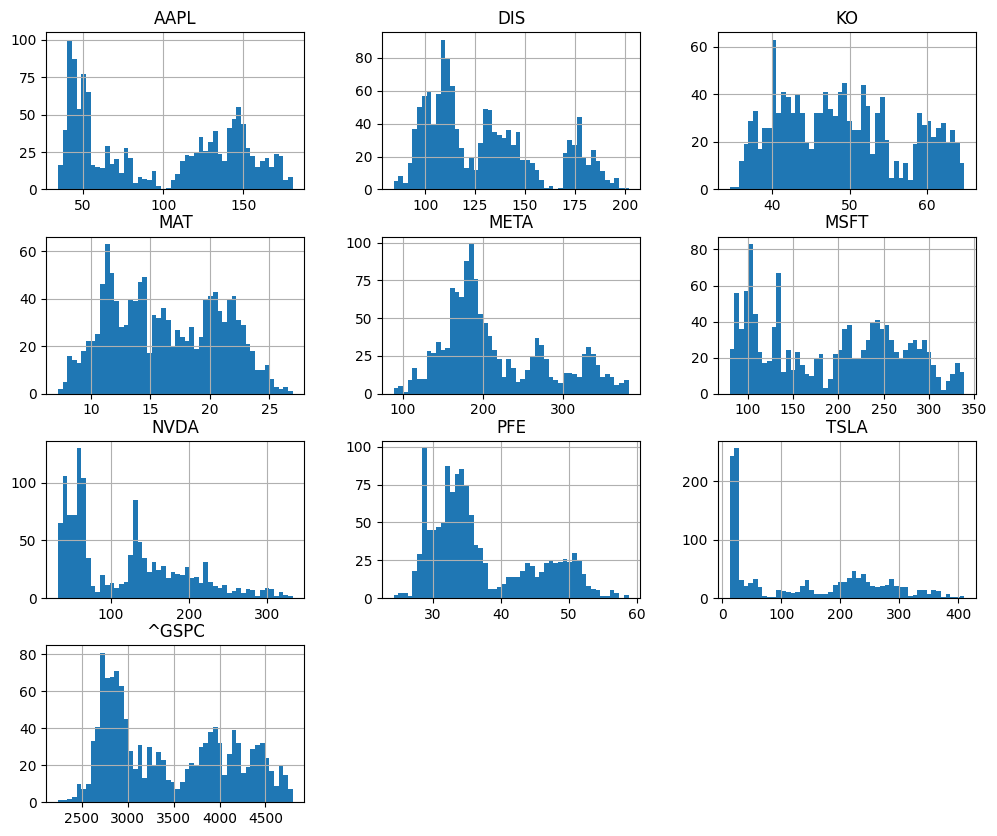

In [83]:
adj_close_data.hist(figsize=(12,10), bins=50);

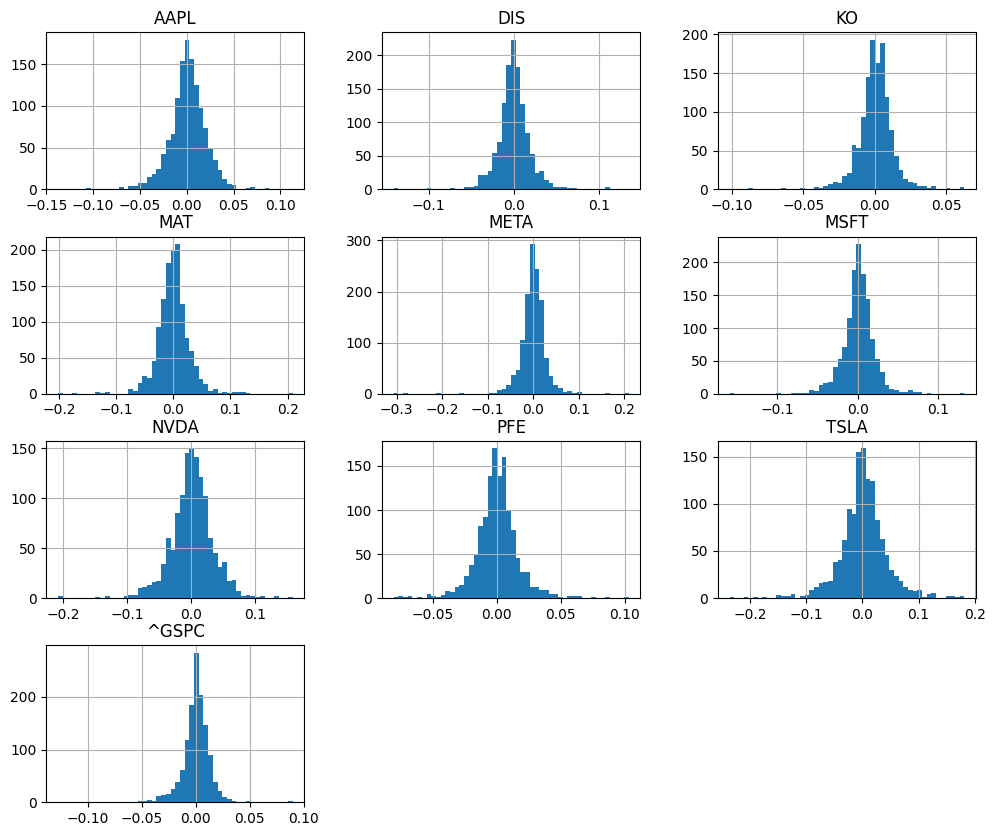

In [19]:
df_log.hist(figsize=(12,10), bins=50);

## Barplots

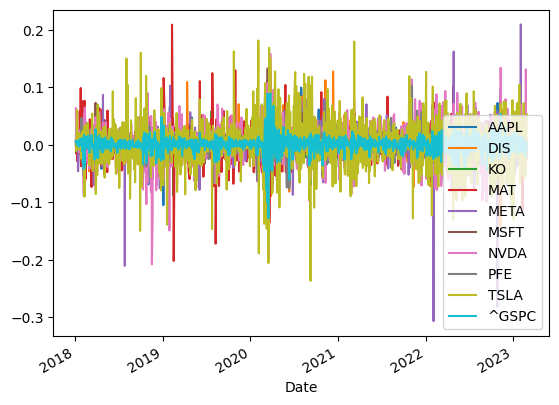

In [20]:
df_log.plot();

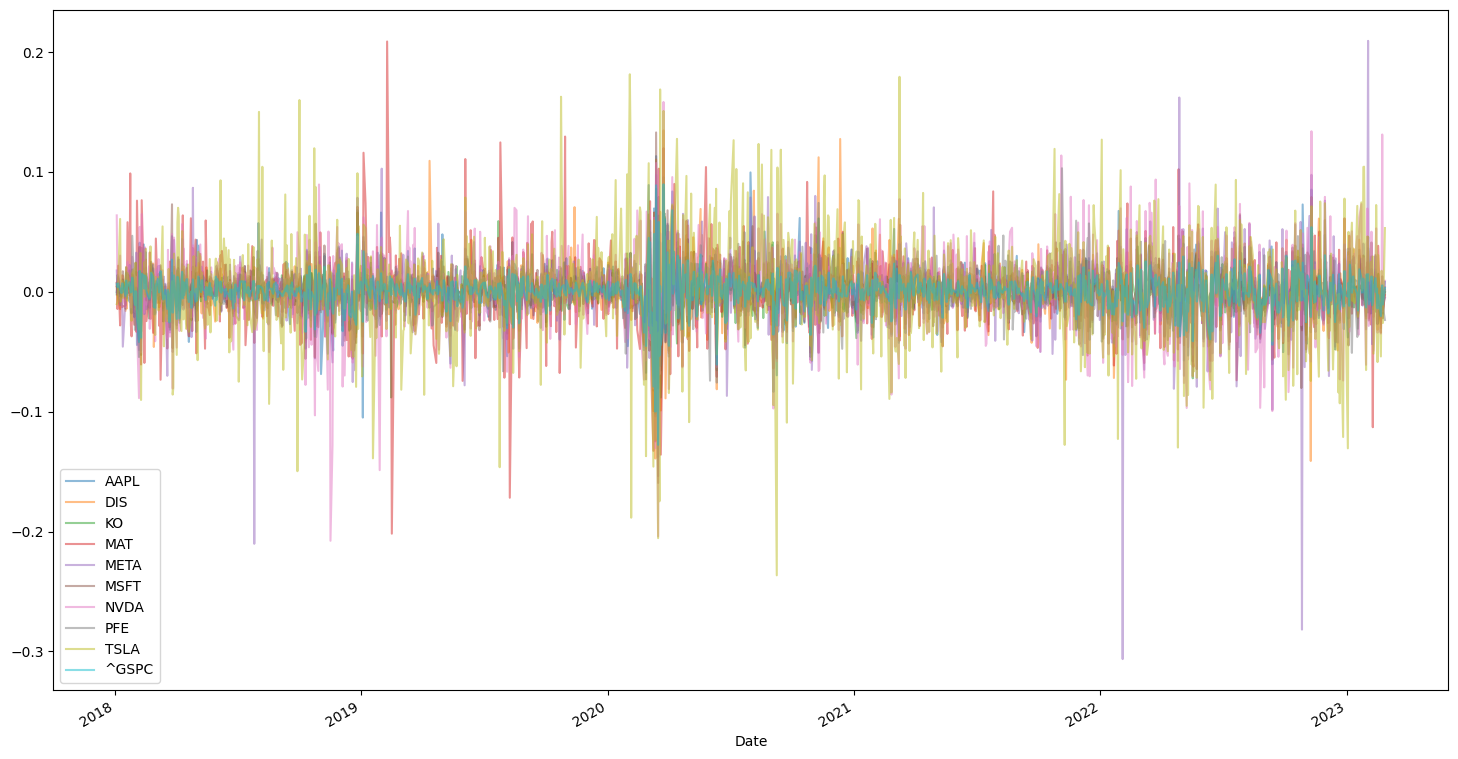

In [21]:
df_log.plot(
    figsize=(18,10),
    alpha=0.5
);

The global minimum and maximum (-0.30639058479708176, 0.20930746959795124)




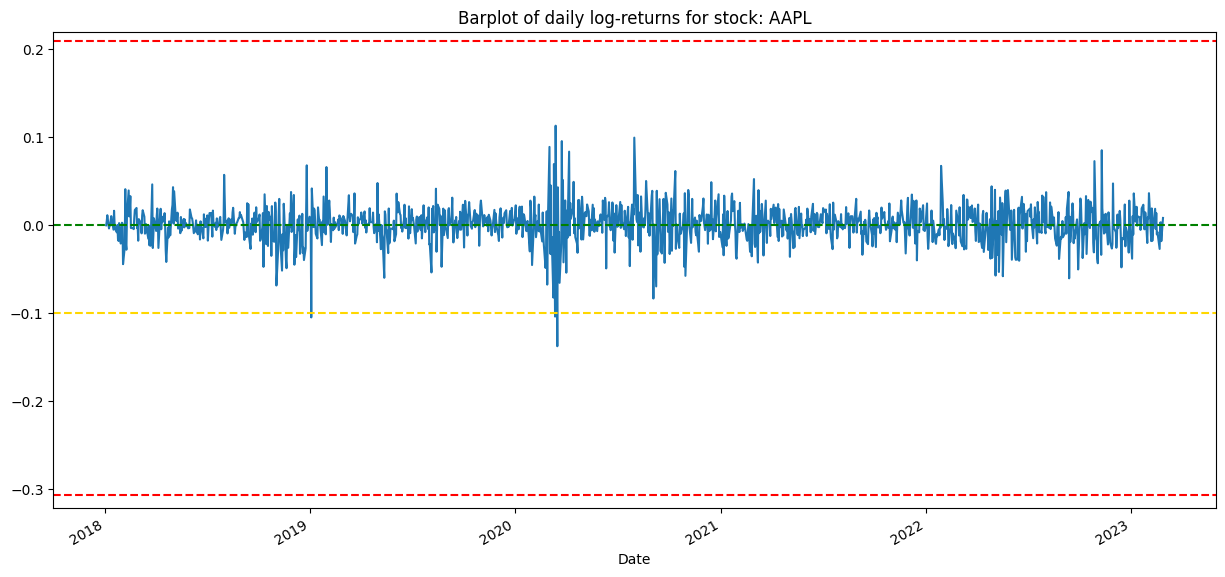

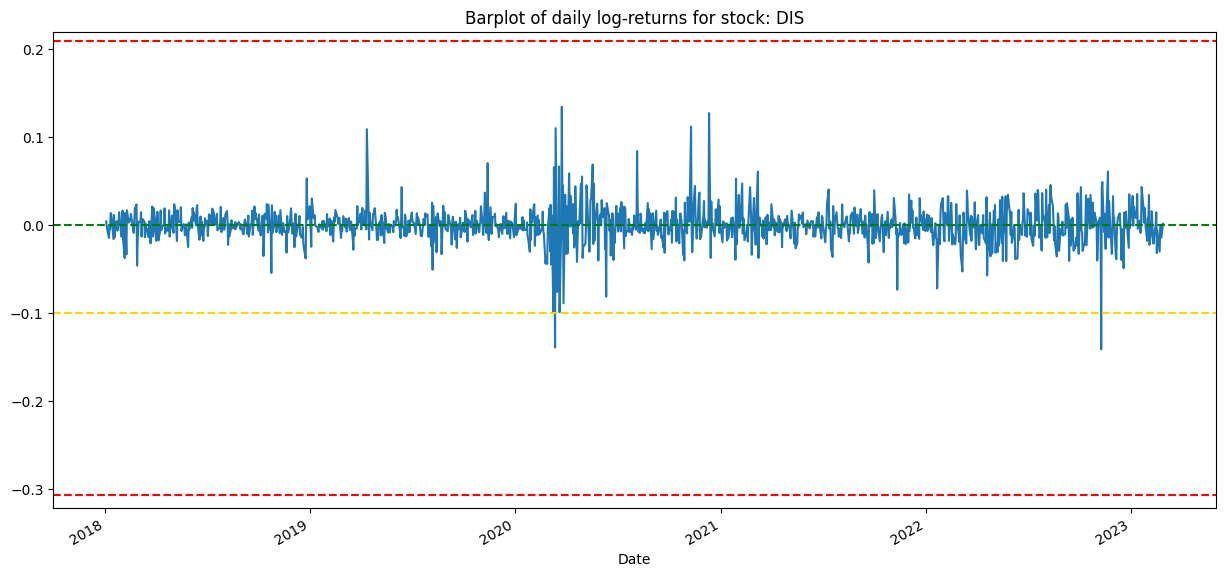

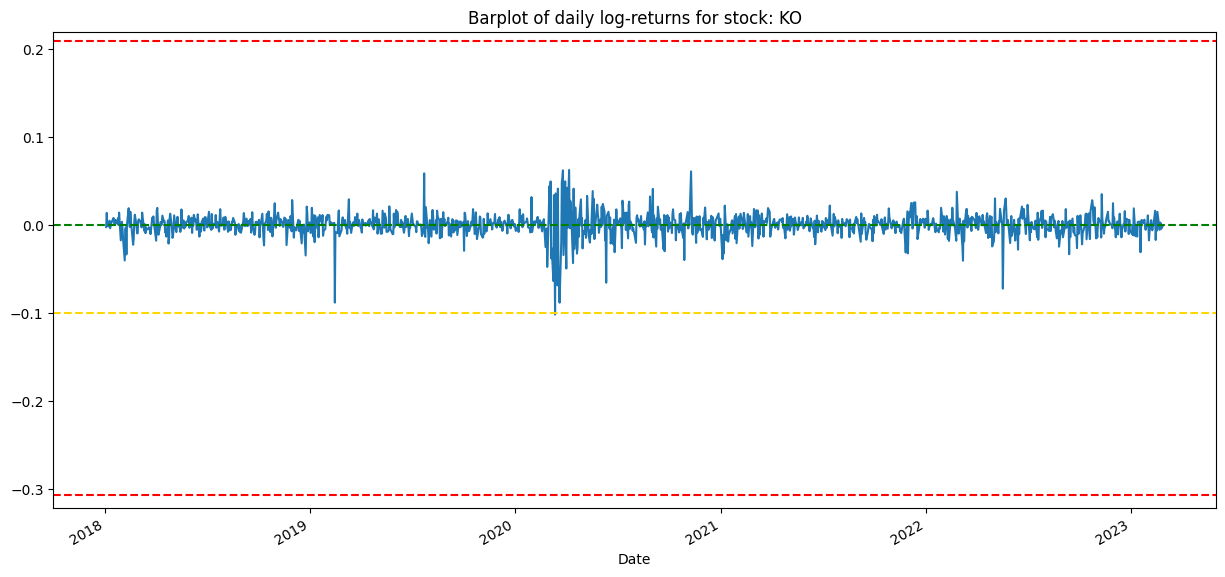

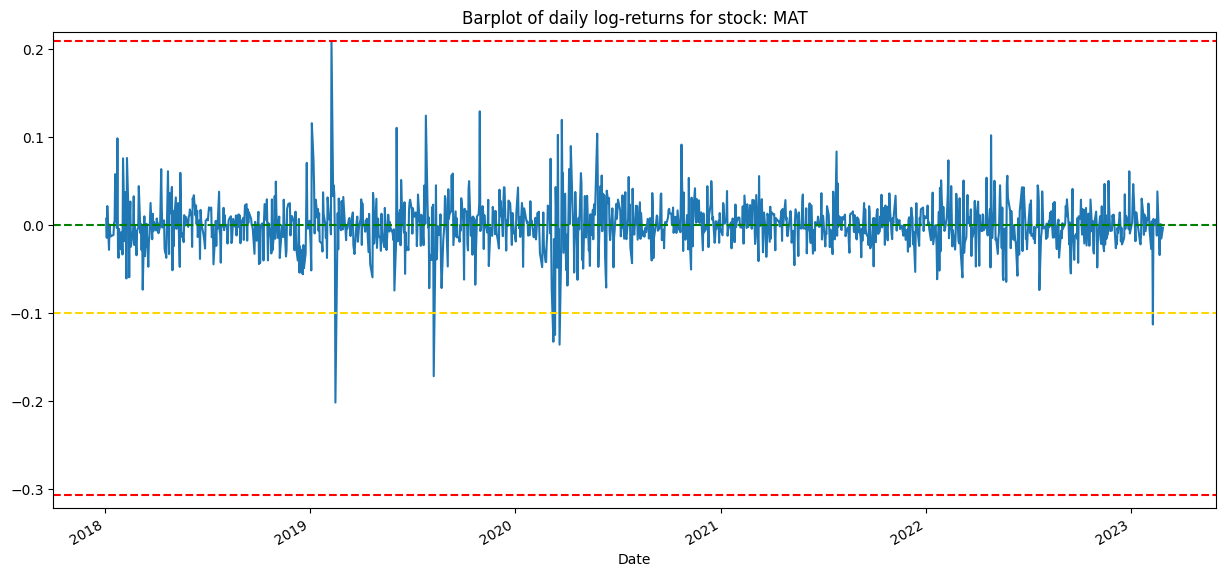

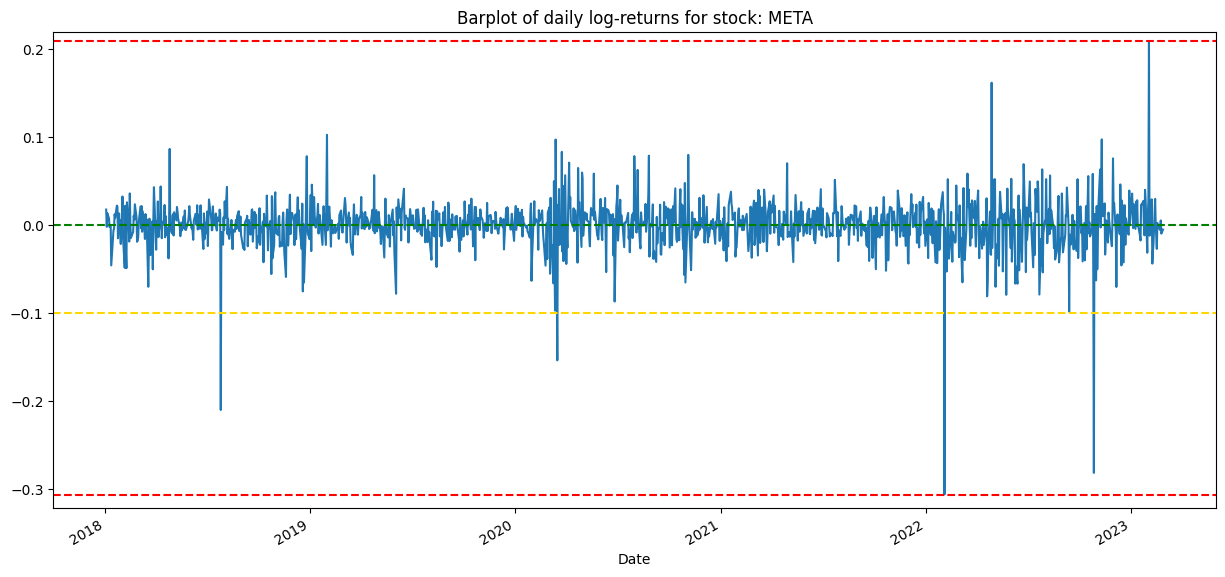

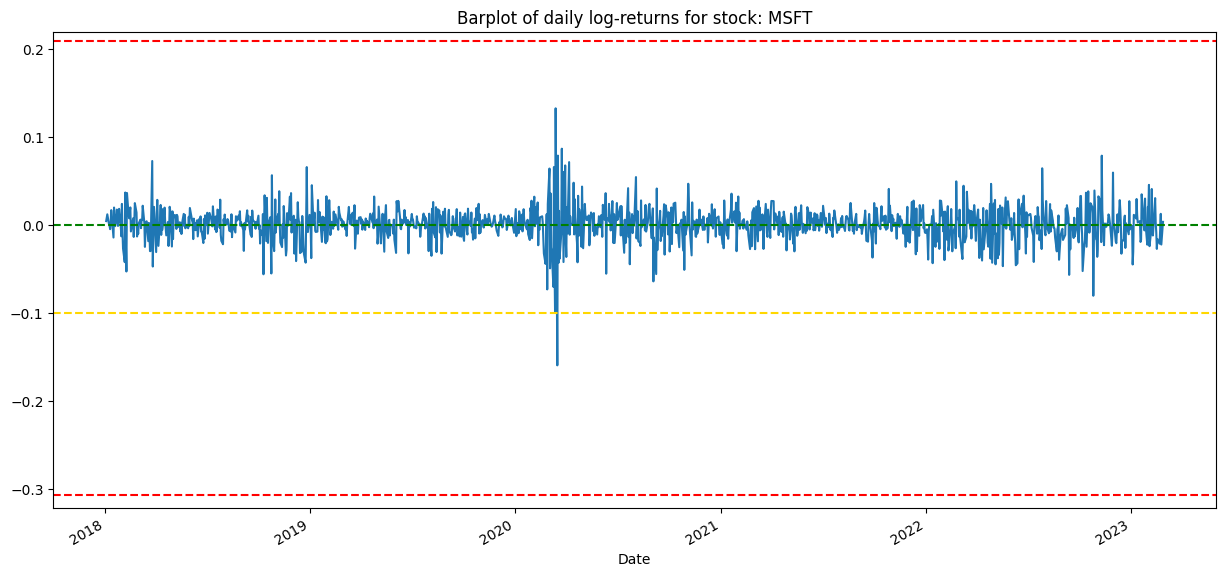

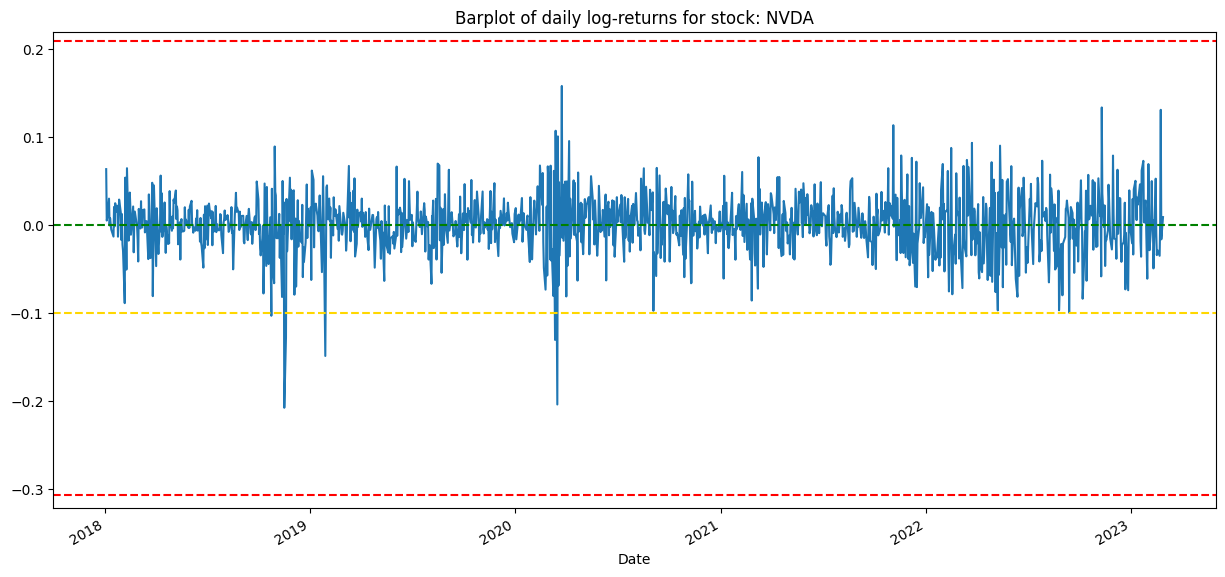

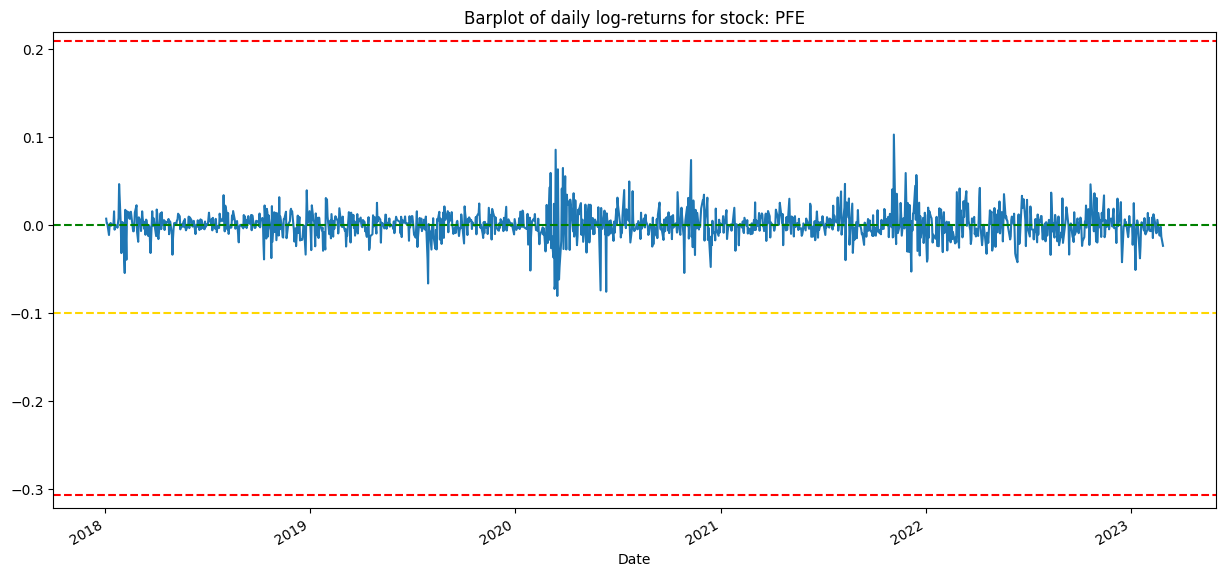

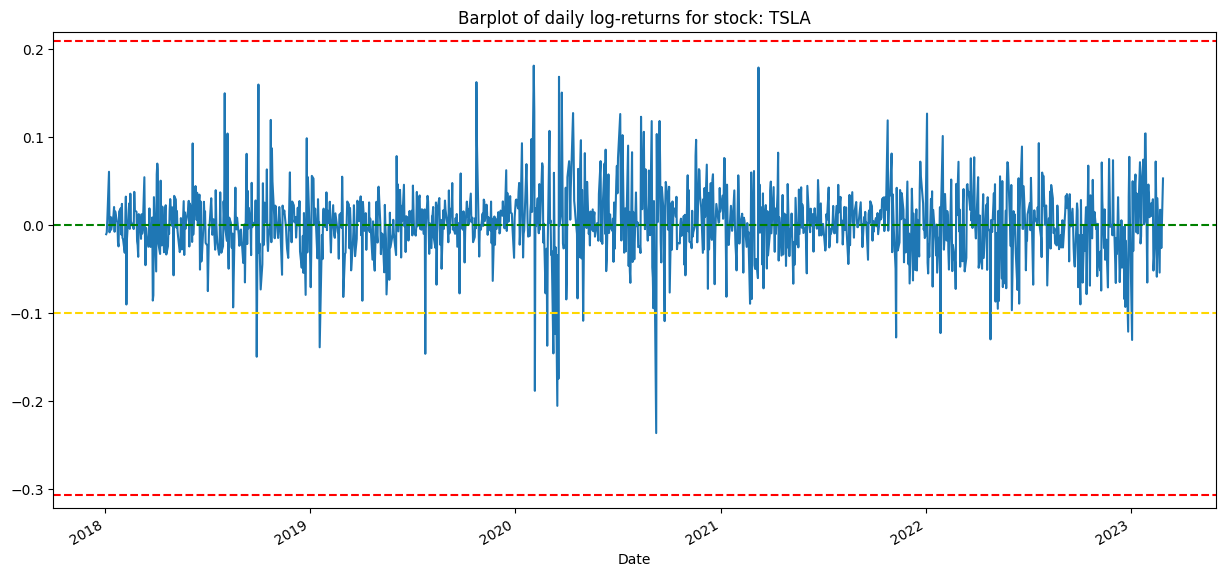

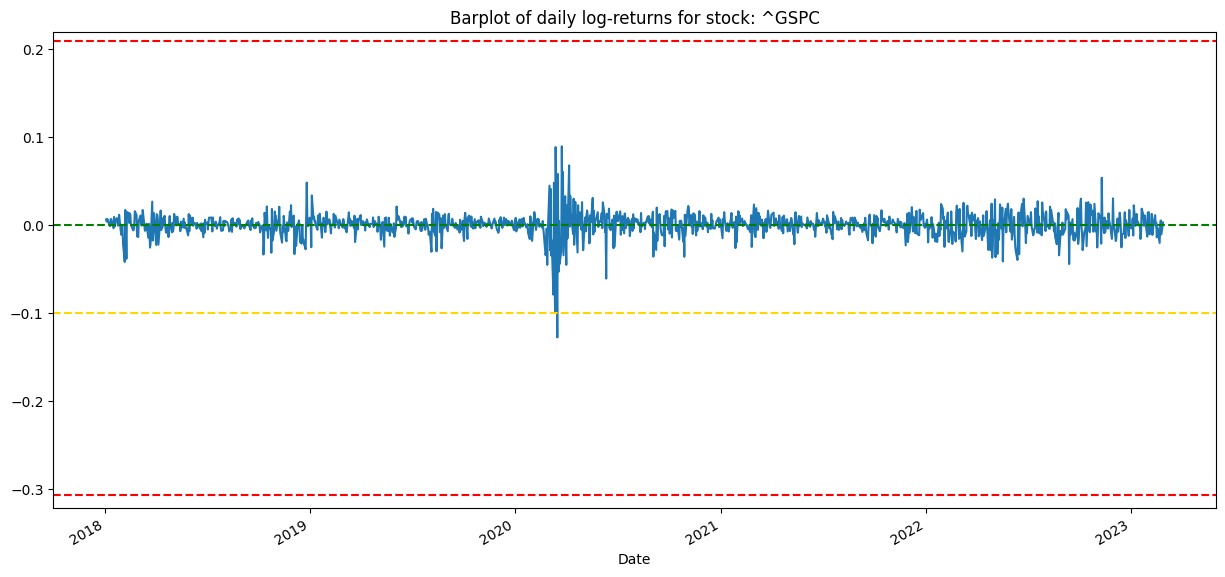

In [22]:
min_scale=df_log.min().min()
max_scale=df_log.max().max()
print(f"The global minimum and maximum {(min_scale, max_scale)}")
# print(f"The global minimum: {min_scale}")
for col in df_log:
    print(f"\n")
    df_log[col].plot(figsize=(15,7))
    plt.title(f"Barplot of daily log-returns for stock: {col}")
    plt.ylim(min_scale*1.05, max_scale*1.05)
    plt.axhline(y = min_scale, color='r', linestyle='--')
    plt.axhline(y = max_scale, color='r', linestyle='--')
    plt.axhline(y = -0.1, color='gold', linestyle='--')
    plt.axhline(y = 0, color='green', linestyle='--')
    plt.show();

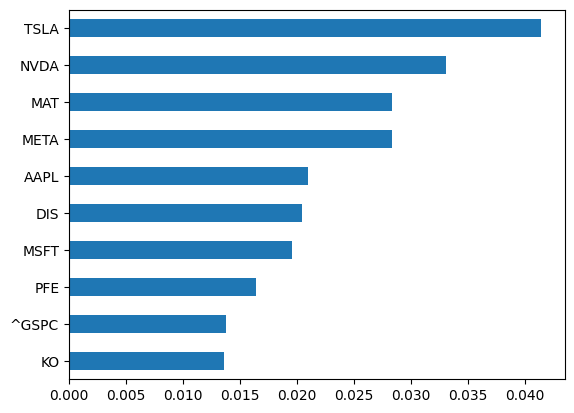

In [56]:
df_log.std().sort_values().plot(kind='barh');

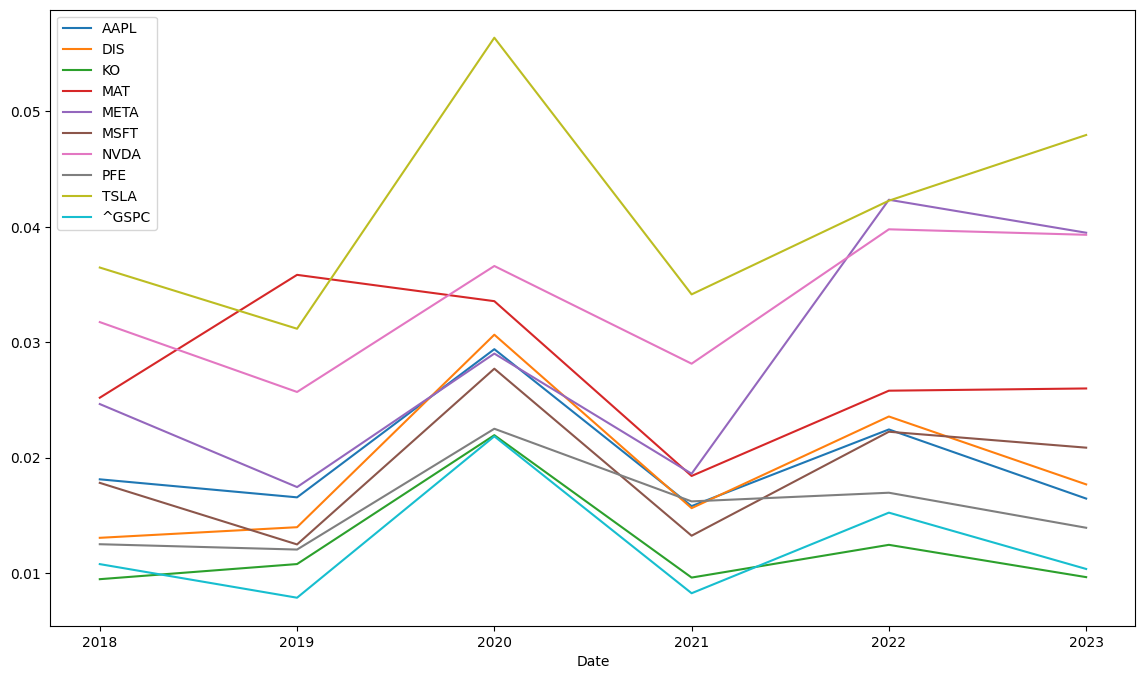

In [57]:
df_log.pivot_table(
    index=df_log.index.year,
    aggfunc='std'
).plot(
    figsize=(14,8)
);

## Lineplot

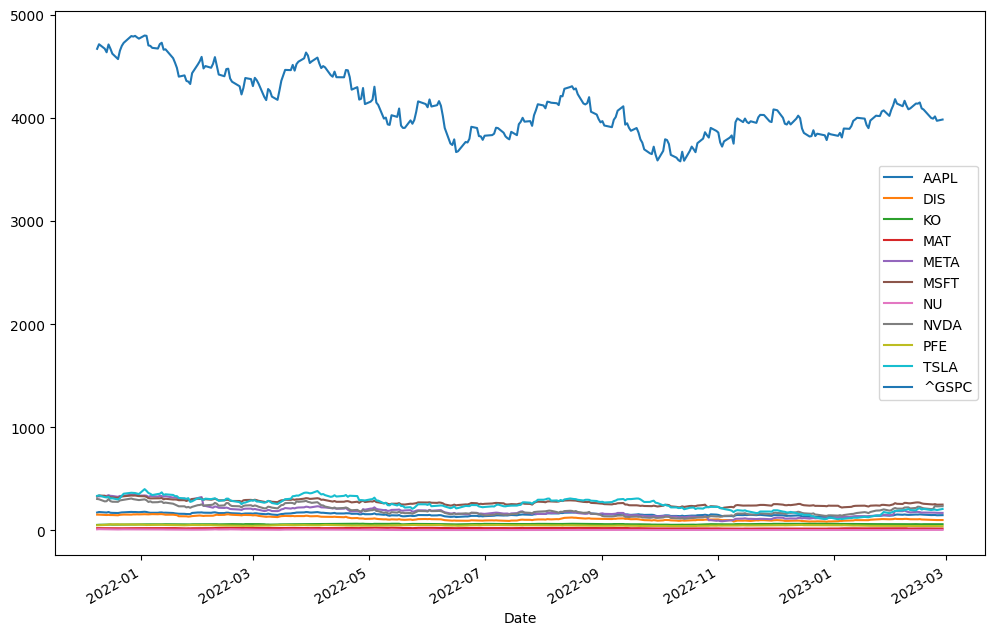

In [95]:
adj_close_data_completed[
    adj_close_data_completed.NU.notna()
].plot(
    figsize=(12,8)
);

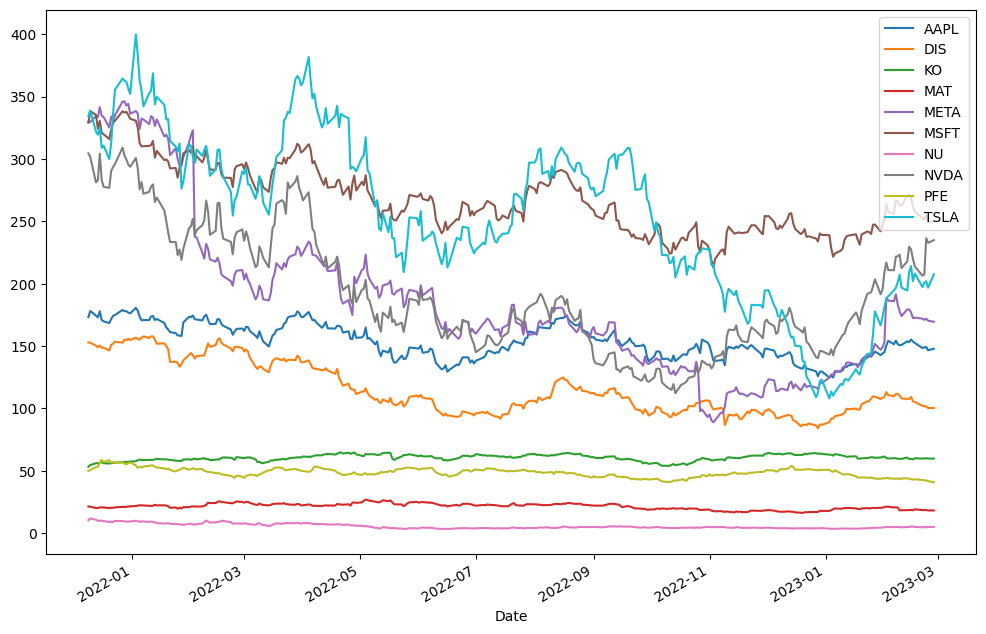

In [84]:
adj_close_data_completed[
    adj_close_data_completed.NU.notna()
].drop(
    columns=["^GSPC"]
).plot(
    figsize=(12,8)
);

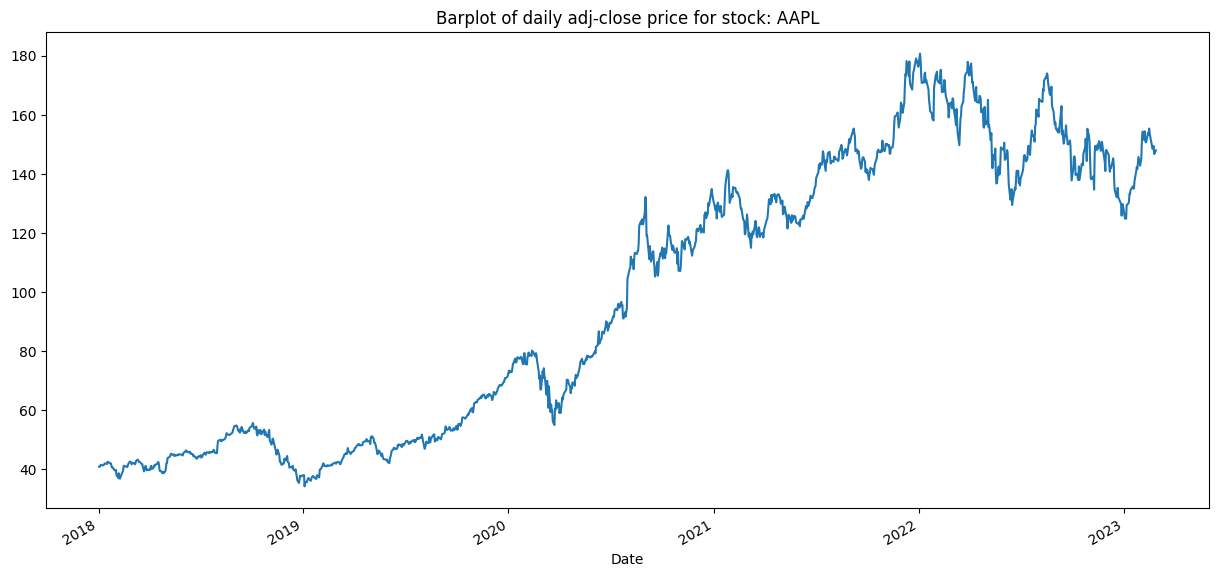

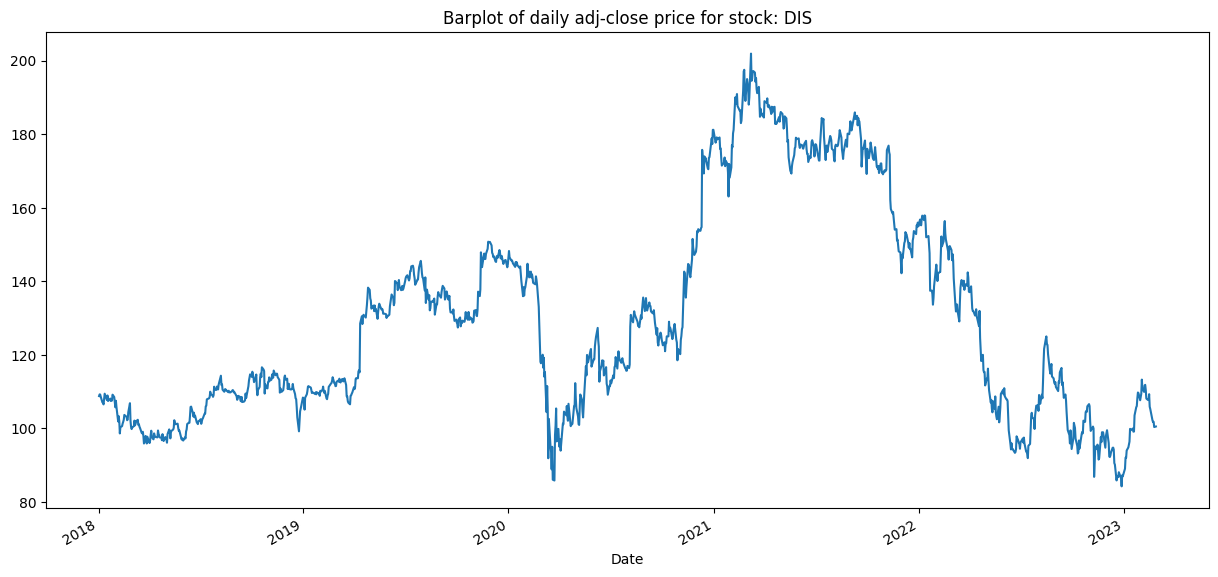

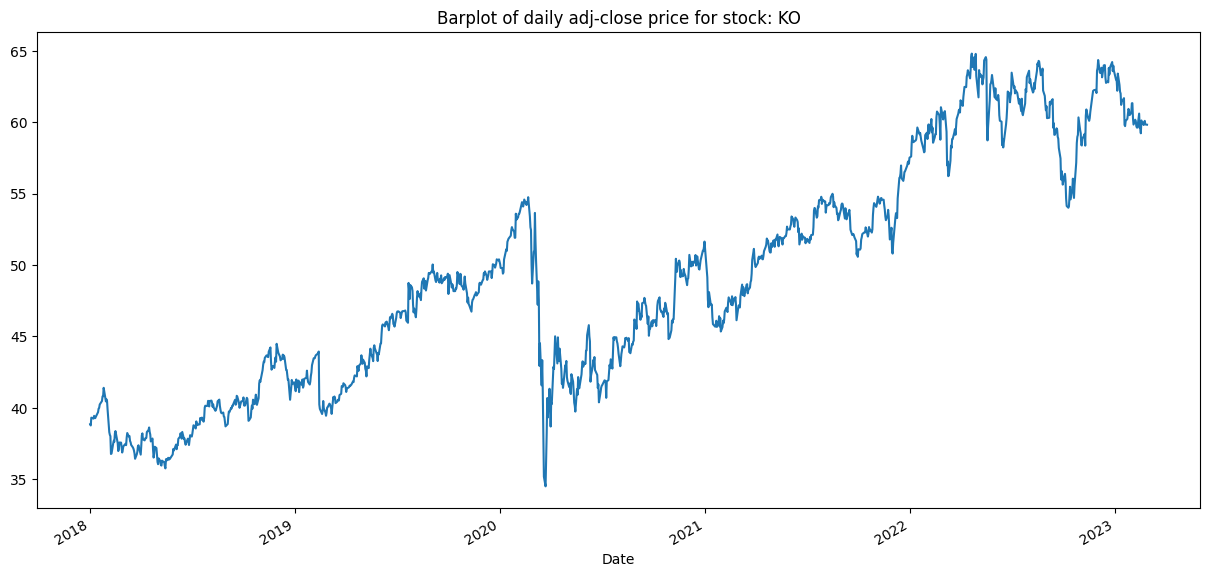

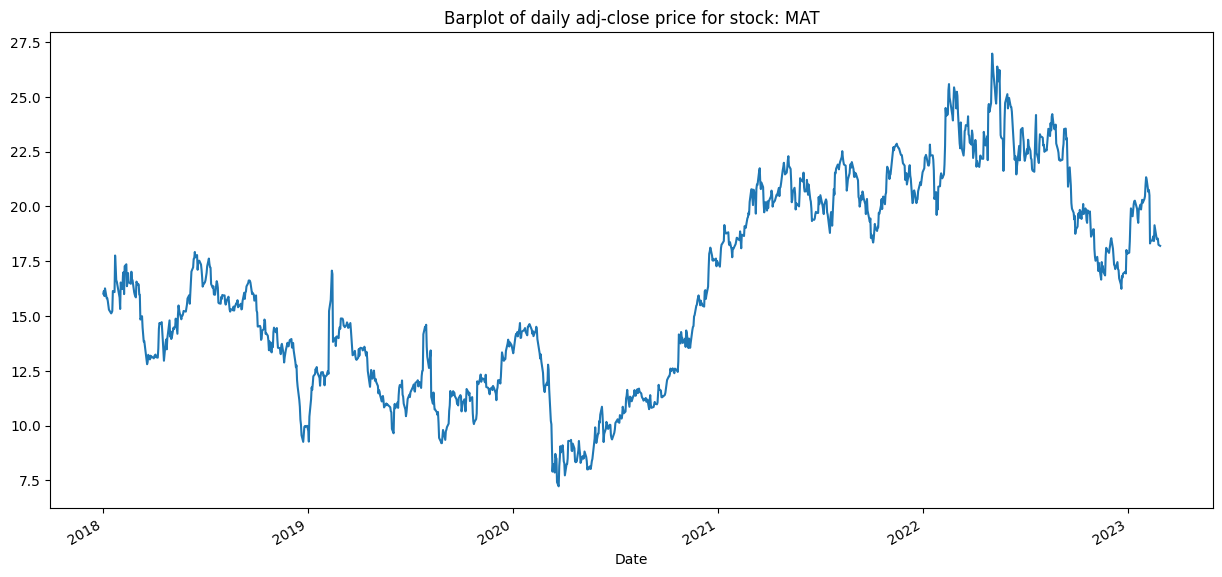

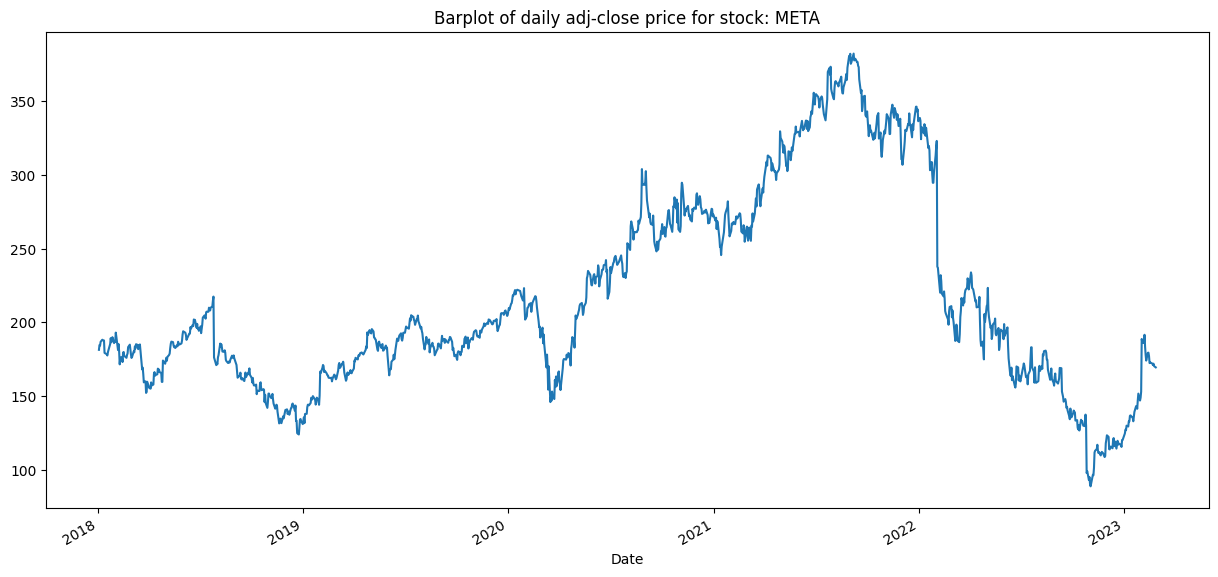

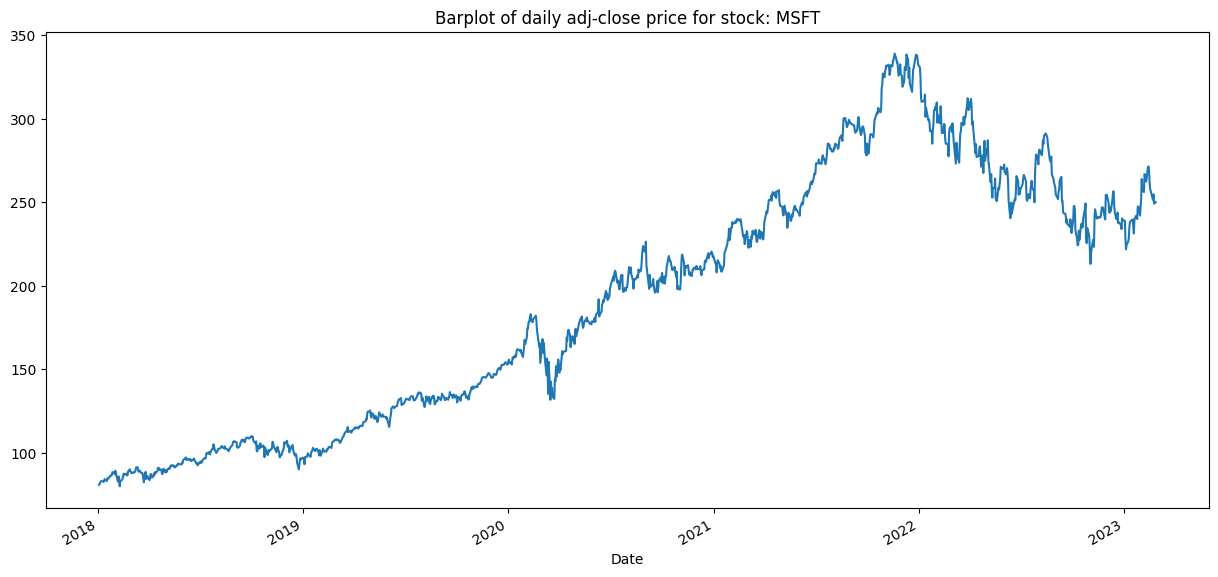

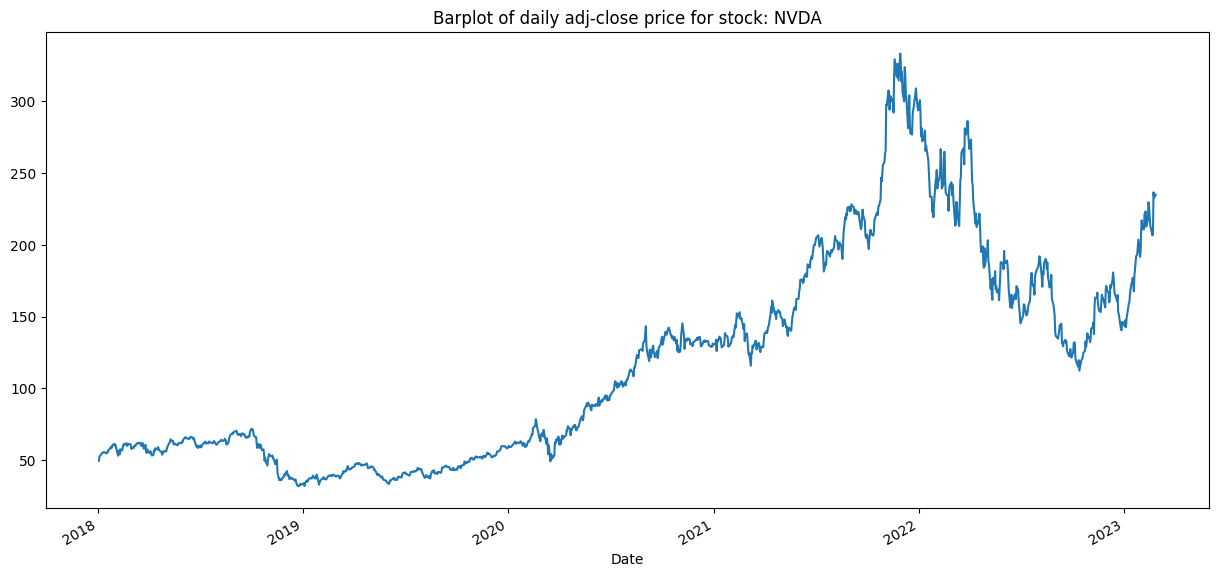

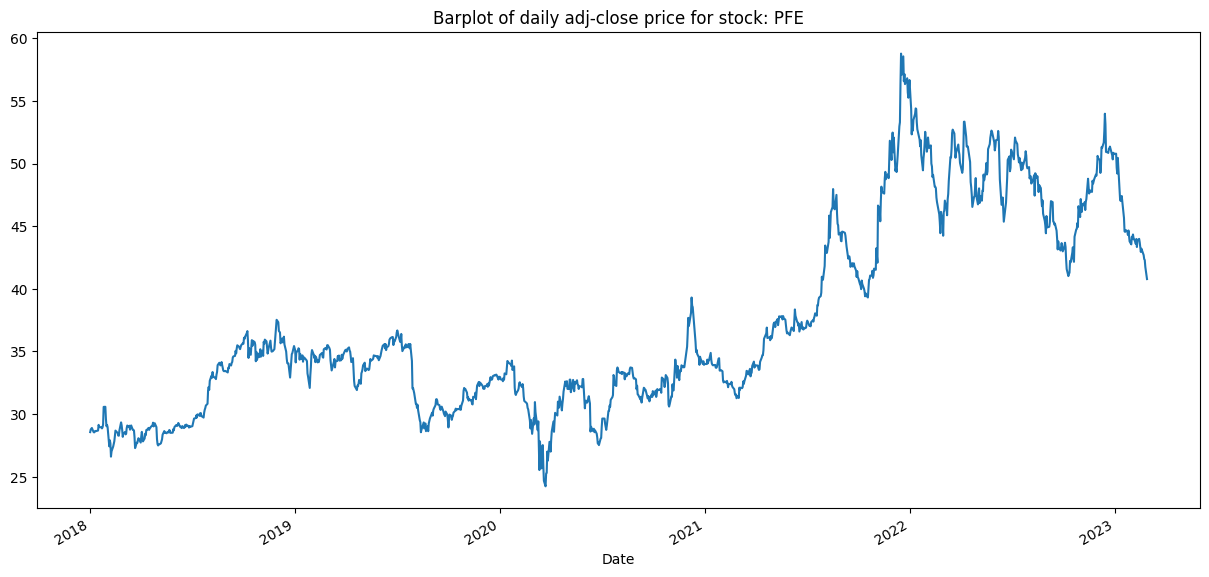

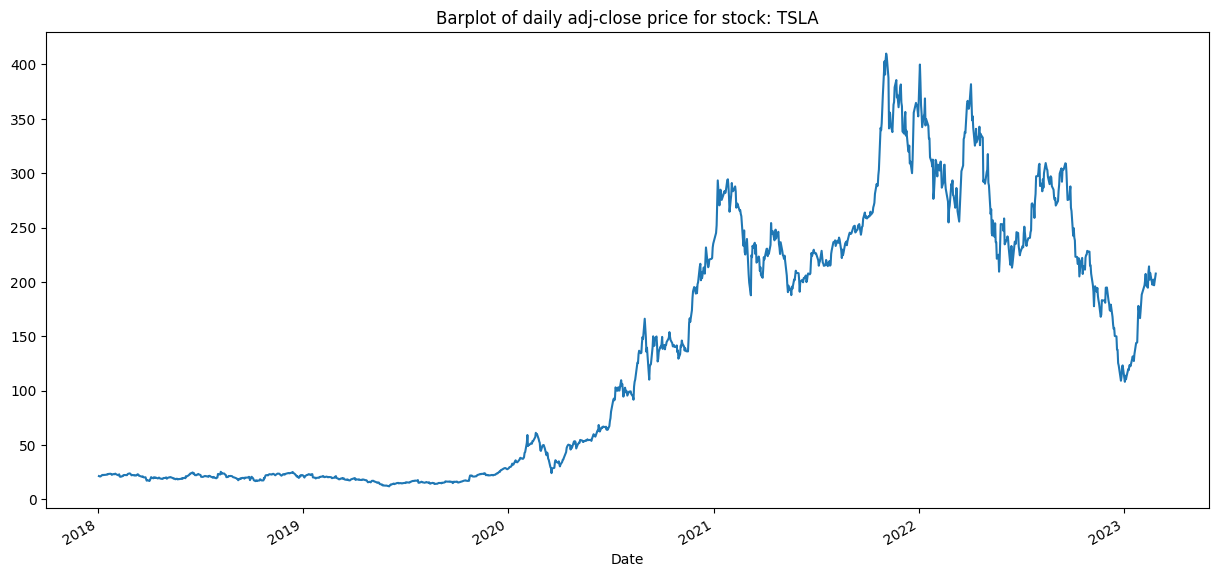

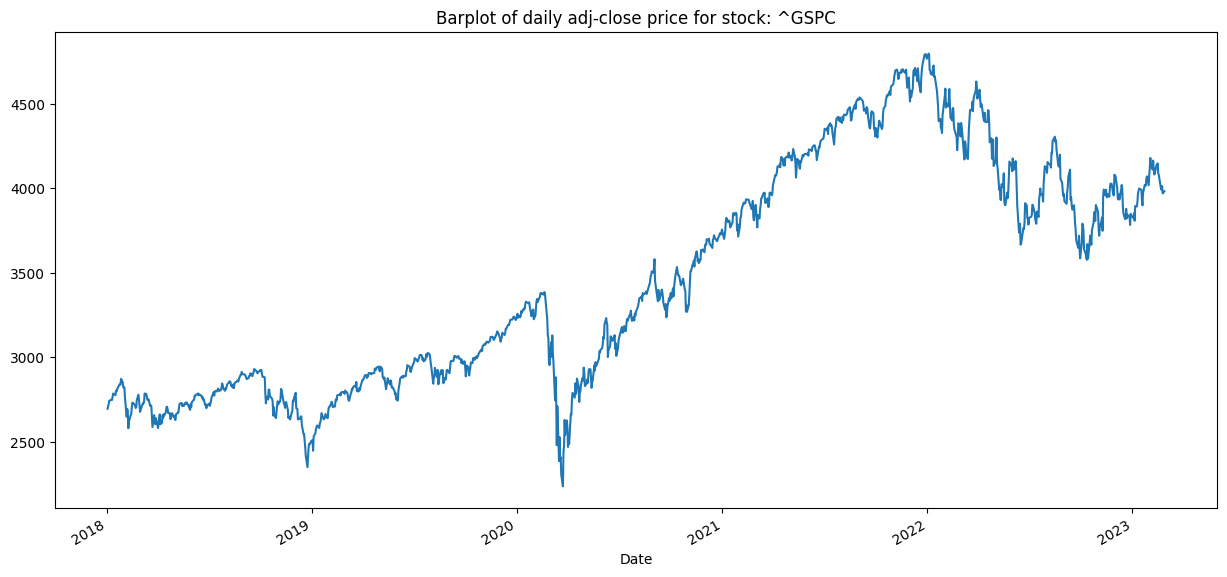

In [85]:
for col in adj_close_data:
    print(f"\n")
    adj_close_data[col].plot(figsize=(15,7))
    plt.title(f"Barplot of daily adj-close price for stock: {col}")
    plt.show();

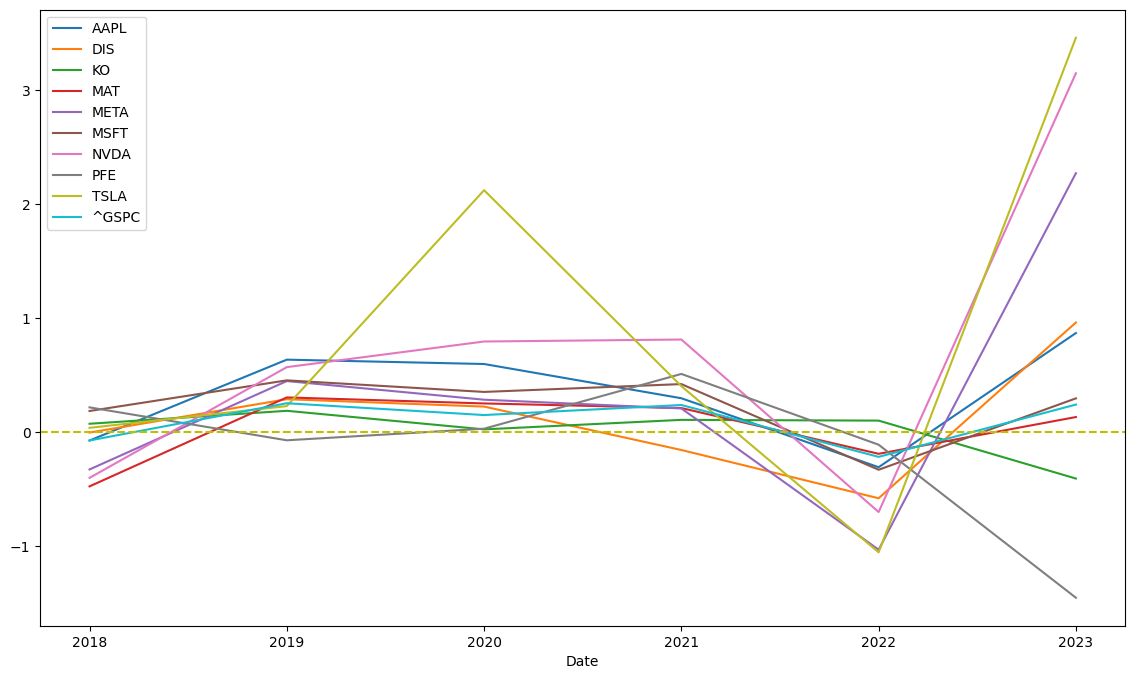

In [41]:
(
    df_log.pivot_table(
        index=df_log.index.year,
        aggfunc='mean'
    )*252
).plot(
    figsize=(14,8)
);
plt.axhline(y=0, color='y', linestyle='--');

## Boxplot

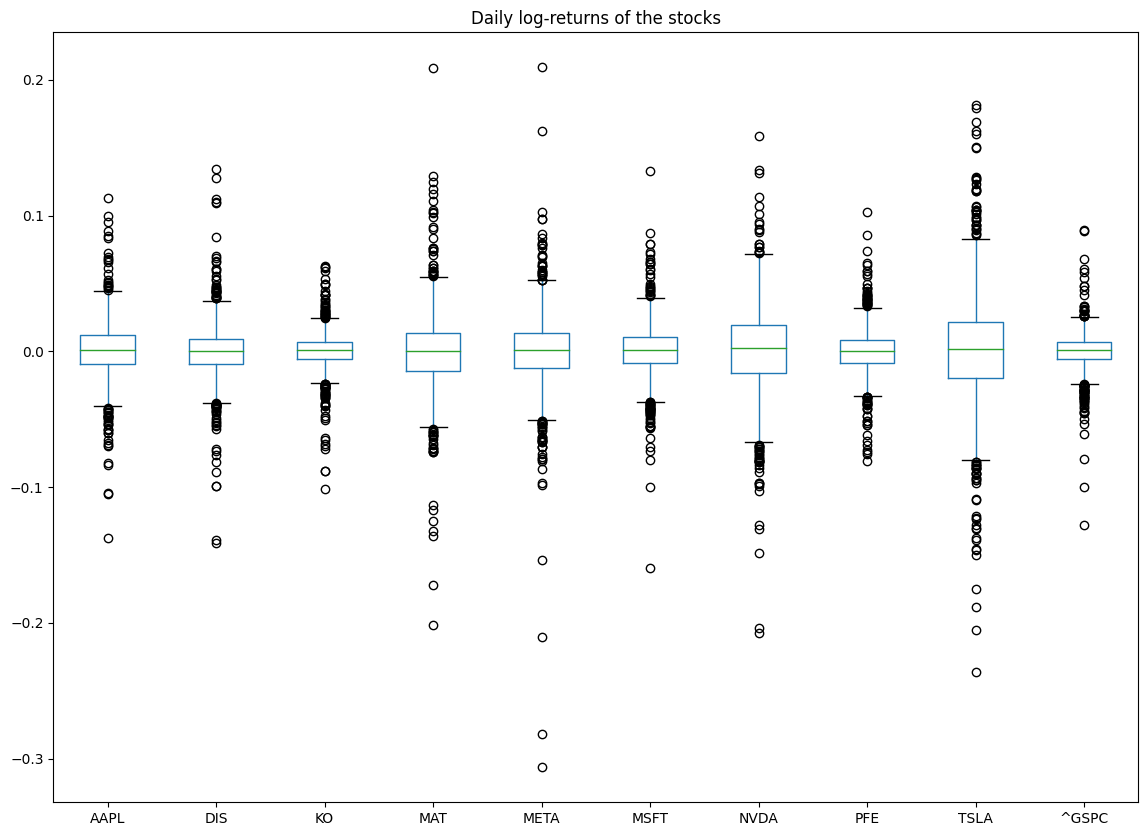

In [86]:
df_log.boxplot(figsize=(14, 10), grid=False)
plt.title("Daily log-returns of the stocks");

## Heatmap

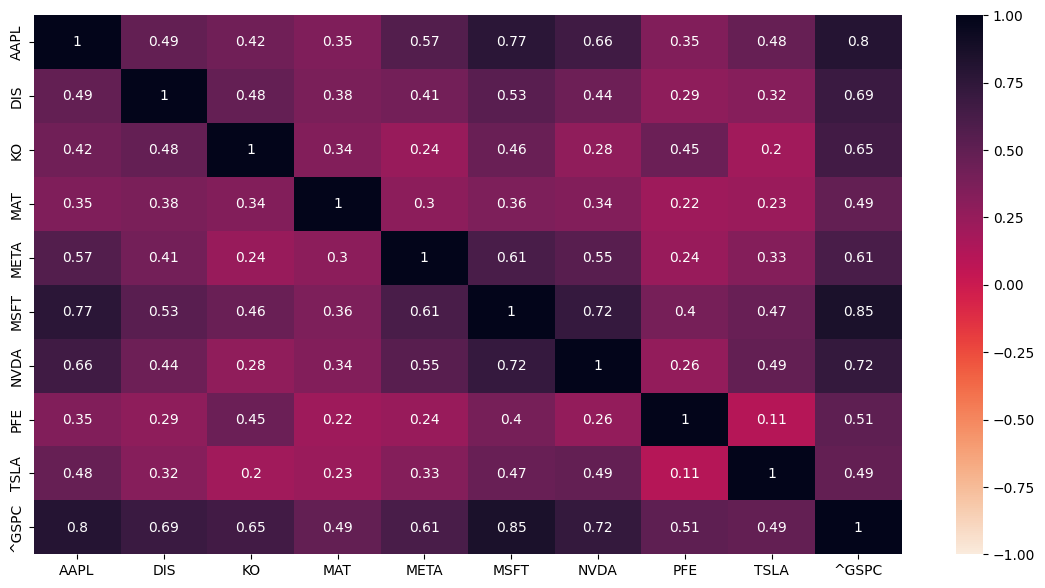

In [98]:
fig, ax = plt.subplots(figsize=(14,7))    
sns.heatmap(
    df_log.corr(method='pearson'), 
    vmin=-1, 
    vmax=1,
    annot=True,cmap="rocket_r",
    ax=ax
)
plt.show()

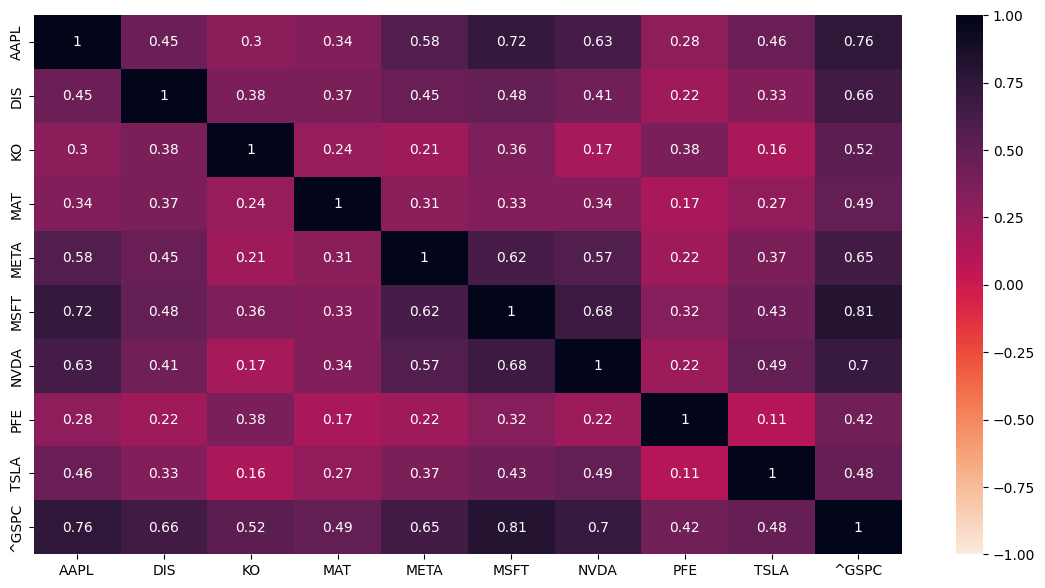

In [97]:
fig, ax = plt.subplots(figsize=(14,7))    
sns.heatmap(
    df_log.corr(method='spearman'), 
    vmin=-1, 
    vmax=1,
    annot=True,cmap="rocket_r",
    ax=ax
)
plt.show()

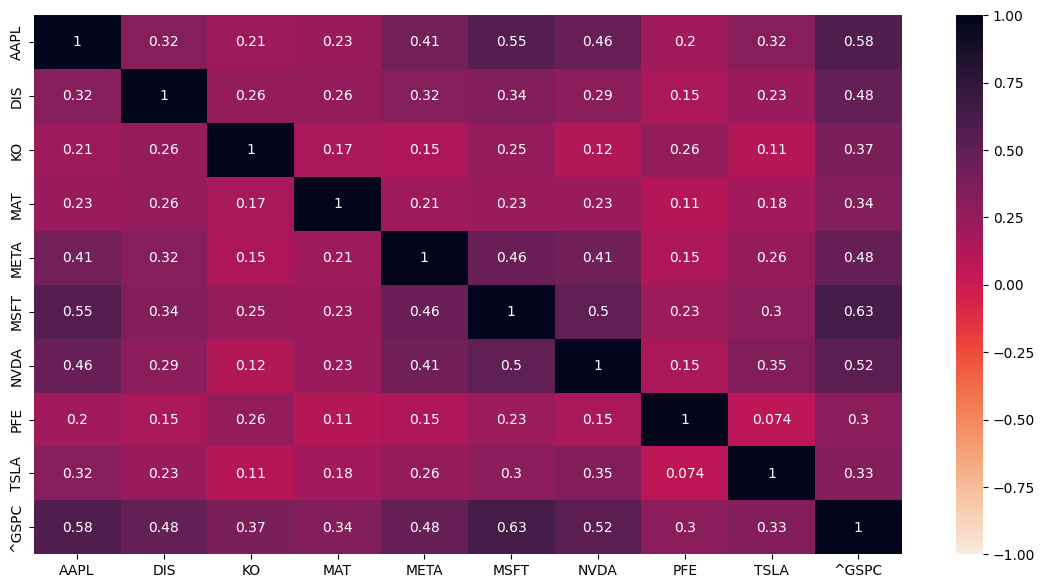

In [96]:
fig, ax = plt.subplots(figsize=(14,7))    
sns.heatmap(
    df_log.corr(method='kendall'), 
    vmin=-1, 
    vmax=1,
    annot=True,cmap="rocket_r",
    ax=ax
)
plt.show()

# References
- https://www.tylervigen.com/spurious-correlations
- https://www.kaggle.com/code/kiyoung1027/correlation-pearson-spearman-and-kendall?scriptVersionId=25999032#679923